# 작업형2

## [가격 예측] 중고 자동차
- 자동차 가격을 예측해주세요!


- 예측할 값(y): price
- 평가: RMSE (Root Mean Squared Error)
- data: train.csv, test.csv
- 제출 형식: result.csv파일을 아래와 같은 형식(수치형)으로 제출
~~~
pred
11000
20500
19610
...
11995
~~~

### 답안 제출 참고
- pd.read_csv('result.csv') 로 제출 코드 확인

In [1]:
# 데이터 불러오기
import pandas as pd

train = pd.read_csv("https://raw.githubusercontent.com/lovedlim/inf/refs/heads/main/p4/5_2/train.csv")
test = pd.read_csv("https://raw.githubusercontent.com/lovedlim/inf/refs/heads/main/p4/5_2/test.csv")

c:\Users\dnwpg\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## EDA

In [2]:
# 데이터 크기 확인
train.shape, test.shape

((3759, 9), (1617, 8))

In [3]:
# 샘플 확인 (시험환경에서는 display 대신 print 활용)
display(train.head(3))
display(test.head(3))

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,EcoSport,2017,10298,Manual,25013,Petrol,150,53.3,1.0
1,Focus,2016,10491,Manual,30970,Diesel,0,74.3,1.5
2,S-MAX,2017,13498,Manual,60200,Diesel,150,56.5,2.0


,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,S-MAX,2016,Manual,23905,Diesel,125,56.5,2.0
1,Fiesta,2018,Manual,16895,Petrol,145,40.3,1.5
2,Kuga,2017,Manual,12109,Petrol,165,45.6,1.5


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3759 entries, 0 to 3758
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         3759 non-null   object 
 1   year          3759 non-null   int64  
 2   price         3759 non-null   int64  
 3   transmission  3759 non-null   object 
 4   mileage       3759 non-null   int64  
 5   fuelType      3759 non-null   object 
 6   tax           3759 non-null   int64  
 7   mpg           3759 non-null   float64
 8   engineSize    3759 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 264.4+ KB


In [5]:
# 기초 통계값 확인
train.describe()

,year,price,mileage,tax,mpg,engineSize
count,3759.000000,3759.000000,3759.000000,3759.000000,3759.000000,3759.000000
mean,2016.887736,12353.321362,23191.786379,114.444001,57.793083,1.352807
std,2.151811,4750.338051,19223.258713,61.713682,10.099221,0.437130
min,2002.000000,1095.000000,5.000000,0.000000,20.900000,0.000000
25%,2016.000000,9000.000000,9997.500000,75.000000,52.300000,1.000000
50%,2017.000000,11495.000000,18180.000000,145.000000,58.900000,1.200000
75%,2018.000000,15310.000000,31000.000000,145.000000,65.700000,1.500000
max,2060.000000,48000.000000,144000.000000,570.000000,201.800000,5.000000


In [6]:
test.describe()

,year,mileage,tax,mpg,engineSize
count,1617.000000,1617.000000,1617.000000,1617.000000,1617.000000
mean,2016.752628,23817.544836,113.089054,57.804082,1.362894
std,2.182152,20130.026364,63.584868,10.567025,0.436878
min,2005.000000,5.000000,0.000000,20.900000,0.000000
25%,2016.000000,10422.000000,30.000000,52.300000,1.000000
50%,2017.000000,18471.000000,145.000000,58.900000,1.200000
75%,2018.000000,31098.000000,145.000000,65.700000,1.600000
max,2020.000000,150890.000000,570.000000,201.800000,5.000000


In [7]:
train.describe(include='O')

,model,transmission,fuelType
count,3759,3759,3759
unique,19,3,3
top,Fiesta,Manual,Petrol
freq,1372,3234,2541


In [8]:
test.describe(include='O')

,model,transmission,fuelType
count,1617,1617,1617
unique,19,3,3
top,Fiesta,Manual,Petrol
freq,591,1385,1085


In [9]:
test['transmission'].value_counts()

transmission
Manual       1385
Automatic     127
Semi-Auto     105
Name: count, dtype: int64

<AxesSubplot:>

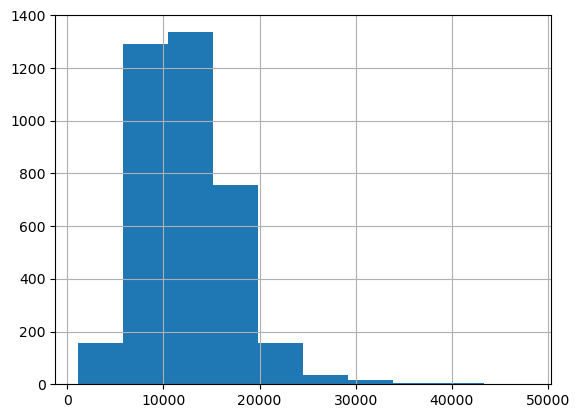

In [10]:
train['price'].hist()

In [11]:
display(train.isnull().sum())
display(test.isnull().sum())

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

model           0
year            0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [12]:
y_train = train.pop("price")

## 수치형 활용

In [13]:
cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
train = train[cols]
test = test[cols]

In [14]:
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(train, y_train, test_size=0.2, random_state=2022)
X_tr.shape, X_val.shape, y_tr.shape, y_val.shape

((3007, 5), (752, 5), (3007,), (752,))

In [15]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_tr, y_tr)
pred = rf.predict(X_val)

In [16]:
from sklearn.metrics import mean_squared_error
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)**0.5

In [17]:
rmse(y_val, pred)

1543.05874222007

## 수치형 + 범주형 활용

In [18]:
train = pd.read_csv("https://raw.githubusercontent.com/lovedlim/inf/refs/heads/main/p4/5_2/train.csv")
test = pd.read_csv("https://raw.githubusercontent.com/lovedlim/inf/refs/heads/main/p4/5_2/test.csv")
y_train = train.pop("price")

In [19]:
train = pd.get_dummies(train)
test = pd.get_dummies(test)

In [20]:
train.shape, test.shape

((3759, 30), (1617, 30))

In [21]:
train.head(2)

,year,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Fiesta,...,model_ Puma,model_ S-MAX,model_ Tourneo Connect,model_ Tourneo Custom,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Hybrid,fuelType_Petrol
0,2017,25013,150,53.3,1.0,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,True
1,2016,30970,0,74.3,1.5,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False


In [22]:
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(train, y_train, test_size=0.2, random_state=2022)
X_tr.shape, X_val.shape, y_tr.shape, y_val.shape

((3007, 30), (752, 30), (3007,), (752,))

In [23]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_tr, y_tr)
pred = rf.predict(X_val)
rmse(y_val, pred)

1299.1810425811339

## Test 예측

In [24]:
pred = rf.predict(test)
result = pd.DataFrame({
    'pred':pred
})
result.to_csv("result.csv", index=False)


In [25]:
pd.read_csv('result.csv')

,pred
0,15351.57
1,16054.21
2,14394.23
3,18692.98
4,6346.06
...,...
1612,11601.91
1613,17762.52
1614,9984.04
1615,14262.49


In [26]:
y = pd.read_csv("https://raw.githubusercontent.com/lovedlim/inf/refs/heads/main/p4/5_2/y.csv")
rmse(y, pred)

1426.7407441265855

In [27]:
pred2 = pred.astype(int)
rmse(y, pred2)

1426.7583314722501

In [28]:
# 데이터 불러오기
import pandas as pd

train = pd.read_csv("https://raw.githubusercontent.com/lovedlim/inf/refs/heads/main/p4/5_2/train.csv")
test = pd.read_csv("https://raw.githubusercontent.com/lovedlim/inf/refs/heads/main/p4/5_2/test.csv")

#eda

print('\n====데이터 크기=====')
print(train.shape,test.shape)

print('\n====데이터 정보=====')
print(train.info())

print('\n====train 결측치=====')
print(train.isnull().sum())

print('\n====test 결측치=====')
print(test.isnull().sum())

print('\n====카테고리=====')
cols=train.select_dtypes(include='O').columns
for col in cols:
  set_train=set(train[col])
  set_test=set(test[col])
  same=set_train==set_test
  if same:
    print(col,'O')
  else:
    print(col,'X')

print('\n====타겟 기초 =====')
print(train['price'].describe())

# 전처리
target=train.pop('price')
train=pd.get_dummies(train)
test=pd.get_dummies(test)
# print(train.shape,test.shape)

#검증
from sklearn.model_selection import train_test_split
X_tr,X_val,y_tr,y_val=train_test_split(train,target,test_size=0.2,random_state=2022)
print(X_tr.shape,X_val.shape,y_tr.shape,y_val.shape)

# rf
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(random_state=0)
rf.fit(X_tr,y_tr)
pred=rf.predict(X_val)

#학습
from sklearn.metrics import root_mean_squared_error
print('===rf===')
print(root_mean_squared_error(y_val,pred))

#lg
import lightgbm as lgb
lg=lgb.LGBMRegressor(random_state=2022,verbose=-1)
lg.fit(X_tr,y_tr)
pred=lg.predict(X_val)
print('==lg==')
print(root_mean_squared_error(y_val,pred))

#lr
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_tr,y_tr)
pred=lr.predict(X_val)
print('==lr==')
print(root_mean_squared_error(y_val,pred))

#결과
pred=lg.predict(test)
submit=pd.DataFrame({'pred':pred})
submit.to_csv('result.csv', index=False)


====데이터 크기=====
(3759, 9) (1617, 8)

====데이터 정보=====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3759 entries, 0 to 3758
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         3759 non-null   object 
 1   year          3759 non-null   int64  
 2   price         3759 non-null   int64  
 3   transmission  3759 non-null   object 
 4   mileage       3759 non-null   int64  
 5   fuelType      3759 non-null   object 
 6   tax           3759 non-null   int64  
 7   mpg           3759 non-null   float64
 8   engineSize    3759 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 264.4+ KB
None

====train 결측치=====
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

====test 결측치=====
model           0
year            0
transmission    0
mileage         0
fuelType    

c:\Users\dnwpg\anaconda3\lib\site-packages\dask\dataframe\__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


==lg==
1282.70065302789
==lr==
2067.5415509210998
